## Import all the necessary config files

In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import re
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'Run'

## Run the coral model

In [3]:
print(growth_rate_df)

   CoralType  GrowthRate_cm_per_year
0  Branching                     3.0
1    Foliose                     3.0
2      Other                     0.8


In [4]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear)

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,2.000000,2.900000,38.100000,43.000000
1,1,2.049691,2.956391,38.180201,43.186283
2,2,2.026188,3.068520,38.891994,43.986702
3,3,2.016049,3.206184,39.240167,44.462400
4,4,2.003318,3.437786,40.276874,45.717977
5,5,0.958371,2.305205,29.858274,33.121849
6,6,1.018436,2.720546,31.209267,34.948249
7,7,0.677995,2.317779,25.683718,28.679491
8,8,0.632030,2.592374,24.411677,27.636080
9,9,0.672134,3.262416,25.468067,29.402617


## Plot the change in total coral cover over the years

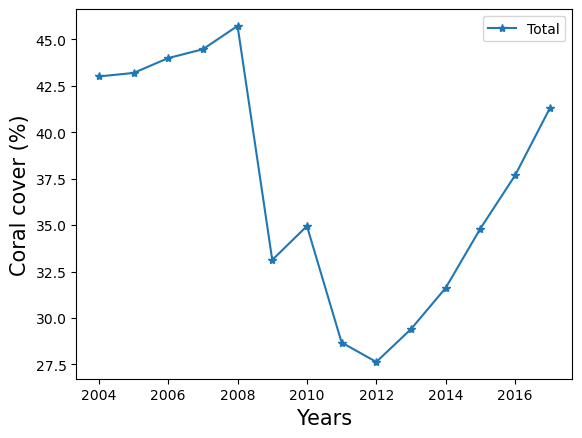

In [5]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [6]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,57.000000,48.000000,6.000000,4.000000,3.000000,35.000000,3.000000,3.000000,3.000000,43.000000,9.000000,100.000000
1,1,56.813717,48.230384,5.983939,4.406572,3.004407,34.906313,3.004407,2.503672,3.004407,43.186283,8.500000,99.916667
2,2,56.013298,47.848545,5.882455,4.703108,3.008142,34.314323,3.008142,2.088987,3.008142,43.986702,8.095207,99.930454
3,3,55.537600,47.722467,5.824905,4.957576,3.011288,33.978612,3.011288,1.742644,3.011288,44.462400,7.757106,99.941973
4,4,54.282023,46.758837,5.664955,5.076074,3.013976,33.045568,3.013976,1.453499,3.013976,45.717977,7.474779,99.951593
5,5,66.878151,55.480589,5.679665,11.180397,3.021802,35.742792,3.021802,5.209891,3.021802,33.121849,11.224349,99.826787
6,6,65.051751,54.521852,5.494688,11.541479,3.028540,34.578709,3.028540,4.351256,3.028540,34.948249,10.385180,99.855281
7,7,71.320509,59.247251,5.504747,14.195149,3.034084,36.621734,5.013807,3.916905,3.034084,28.679491,11.942932,99.869675
8,8,72.363920,60.479544,5.486254,15.123358,3.038706,36.923367,5.446105,3.307423,3.038706,27.636080,11.774296,99.889920
9,9,70.597383,59.264512,5.324729,15.138063,3.042666,35.836279,5.453202,2.759777,3.042666,29.402617,11.240998,99.908127


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

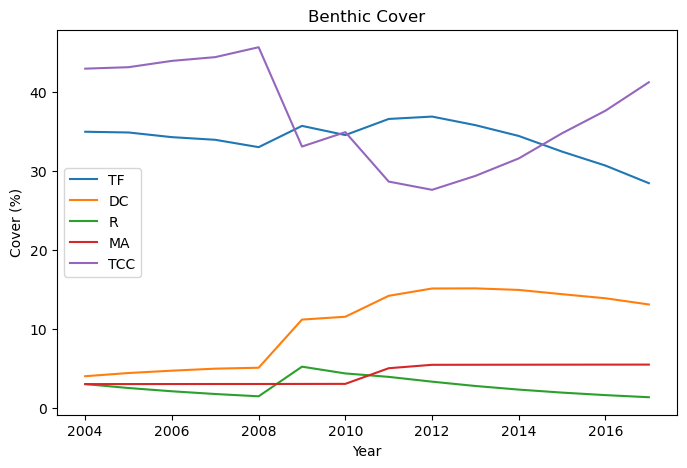

In [7]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [8]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots - please enter the years (within model range) for each plot

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

Error: Requested year 2022 is after the end year 2017. Please use years up to 2017.


In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

Error: Requested year 2022 is after the end year 2017. Please use years up to 2017.


In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

Error: Requested year 2022 is after the end year 2017. Please use years up to 2017.


In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

Error: Requested year 2022 is after the end year 2017. Please use years up to 2017.


In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

Error: Requested year 2020 is after the end year 2017. Please use years up to 2017.


In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2022
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

Error: Requested year 2022 is after the end year 2017. Please use years up to 2017.


## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

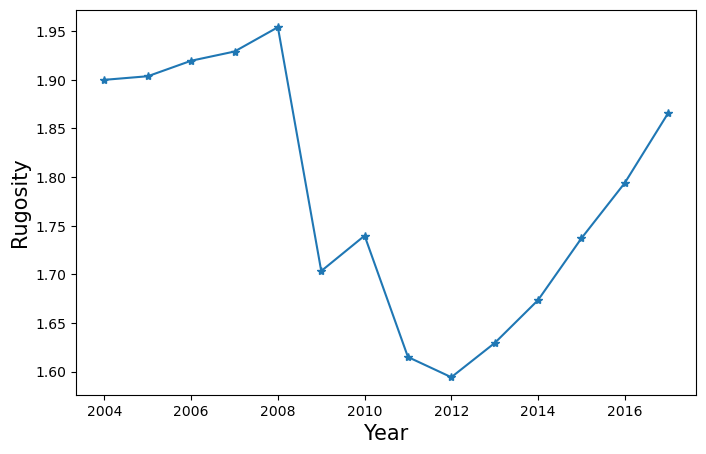

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

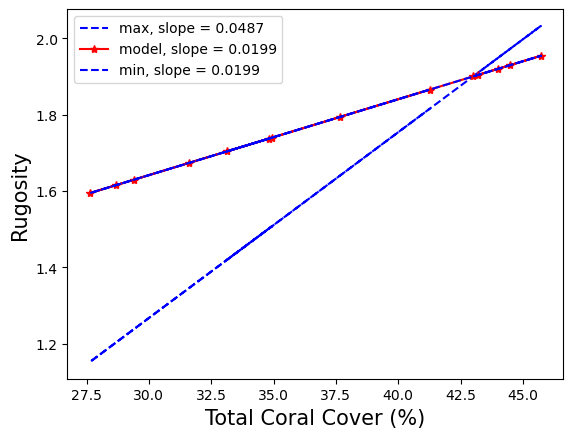

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

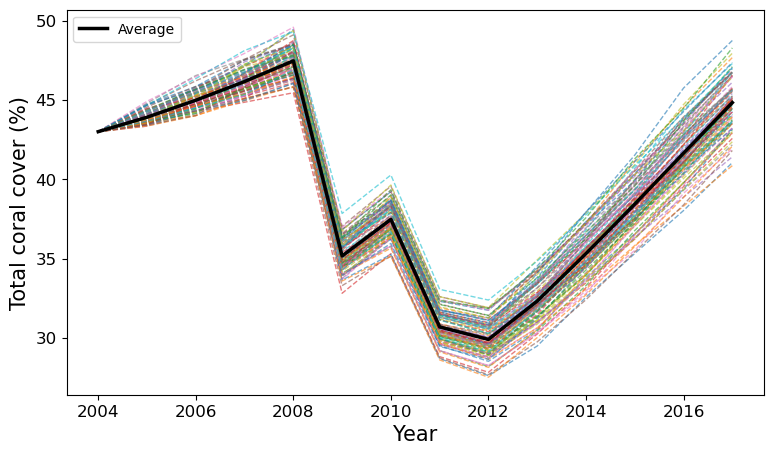

In [18]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [19]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,...,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
1,1,44.004540,44.439150,43.700159,43.504595,43.947746,43.563460,43.825734,44.797007,44.169091,...,43.741981,44.382287,43.451394,44.123194,43.419085,43.900789,44.364115,43.805972,43.653663,43.908742
2,2,44.521252,45.454423,44.969357,44.261984,44.625759,45.259449,45.438011,46.536087,45.382313,...,44.635104,45.678163,44.780651,44.858078,44.016210,44.837973,45.474533,45.083260,44.504253,44.978965
3,3,45.646892,46.495636,46.129777,44.853973,45.593977,46.347529,46.442939,47.569828,46.308129,...,45.375625,46.908783,45.739292,46.335864,45.816738,45.810725,46.655937,47.254798,45.338655,46.156123
4,4,46.581620,48.303988,48.285633,45.450566,46.554210,47.432352,48.411135,48.514096,47.944067,...,46.466545,47.810476,47.216813,47.374015,47.155736,46.885562,48.097290,48.293820,46.894354,47.457990
5,5,34.769681,35.765196,35.955164,32.820530,33.746762,35.521303,36.421254,35.830806,36.501417,...,33.591642,36.329779,34.934048,35.111678,34.925849,35.197570,36.140618,35.841056,34.293152,35.171885
6,6,37.343204,37.607685,37.928287,35.316329,36.409012,38.354403,38.437724,38.472506,38.458022,...,35.145910,39.336641,37.265572,37.634836,37.449884,37.338105,38.369148,38.919185,36.684465,37.475251
7,7,30.487488,30.900705,31.159396,28.829767,29.758393,31.460949,31.505423,31.533834,31.642033,...,28.620213,32.384754,30.414887,30.708381,30.760806,30.602303,31.567646,31.967453,29.998391,30.699275
8,8,29.683829,30.153242,30.264808,27.844711,29.016516,30.829126,30.774227,30.850224,30.877271,...,27.533340,31.864683,29.659708,30.057728,30.013333,29.905223,30.762662,31.269626,29.146234,29.913556
9,9,31.991231,32.859852,32.318918,30.253743,31.626266,33.160502,33.530591,33.492176,32.979635,...,30.029041,34.365696,32.088051,32.674419,32.087776,32.298194,33.553162,33.995734,31.800163,32.331556


In [20]:
# Real data input should be saved in the coral_data_and_custom_parameters.xlsx file
# Load the Excel file into a DataFrame

# Load Excel
real_df_raw = pd.read_excel("coral_data_and_custom_parameters.xlsx", sheet_name="Real_Cover")

# Fill + mask (returns a tuple)
real_df, created = fill_nans_columnwise(
    real_df_raw,
    year_col='Year',
    make_full_years=False,
    fallback='mean',
    return_mask=True
)

# Make Year integer-like for display
real_df['Year'] = pd.to_numeric(real_df['Year'], errors='coerce').round().astype('Int64')

value_cols = [c for c in real_df.columns if c != 'Year']

# Build red-highlight styles
styles = created.reindex_like(real_df).replace({True: 'color: red', False: ''})

# Display with exactly 2 decimals (and integer Year)
styler = (
    real_df.style
           .format({c: '{:.2f}' for c in value_cols})
           .format({'Year': '{:.0f}'})
           .apply(lambda _: styles, axis=None)
)
display(styler)


,Year,RealBranching_Area (%),RealFoliose_Area (%),RealOther_Area (%)
0,2004,2.000000,2.900000,38.100000
1,2005,1.000000,4.500000,41.200000
2,2006,1.250000,4.500000,41.400000
3,2007,1.500000,4.000000,41.800000
4,2008,1.250000,4.000000,41.800000
5,2009,1.000000,2.500000,38.500000
6,2010,1.000000,2.500000,40.000000
7,2011,1.000000,2.400000,32.600000
8,2012,1.000000,2.400000,32.600000
9,2013,1.000000,3.700000,31.300000


## Run the model through a number iterations for all parameters and export results

In [21]:
final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.000000          2.900000       38.100000   
1      1            2.118482          3.110682       38.883290   
2      2            2.239504          3.326492       39.386822   
3      3            2.352991          3.706934       39.947843   
4      4            2.450569          4.167193       40.723600   
..   ...                 ...               ...             ...   
9      9            0.849703          4.085641       25.966510   
10    10            0.938335          5.209998       27.706992   
11    11            1.007489          6.563808       29.972139   
12    12            1.067130          8.075857       31.552576   
13    13            1.106469          9.817340       33.294579   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               43.000000                57.000000                48.000000   
1               44.112454        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

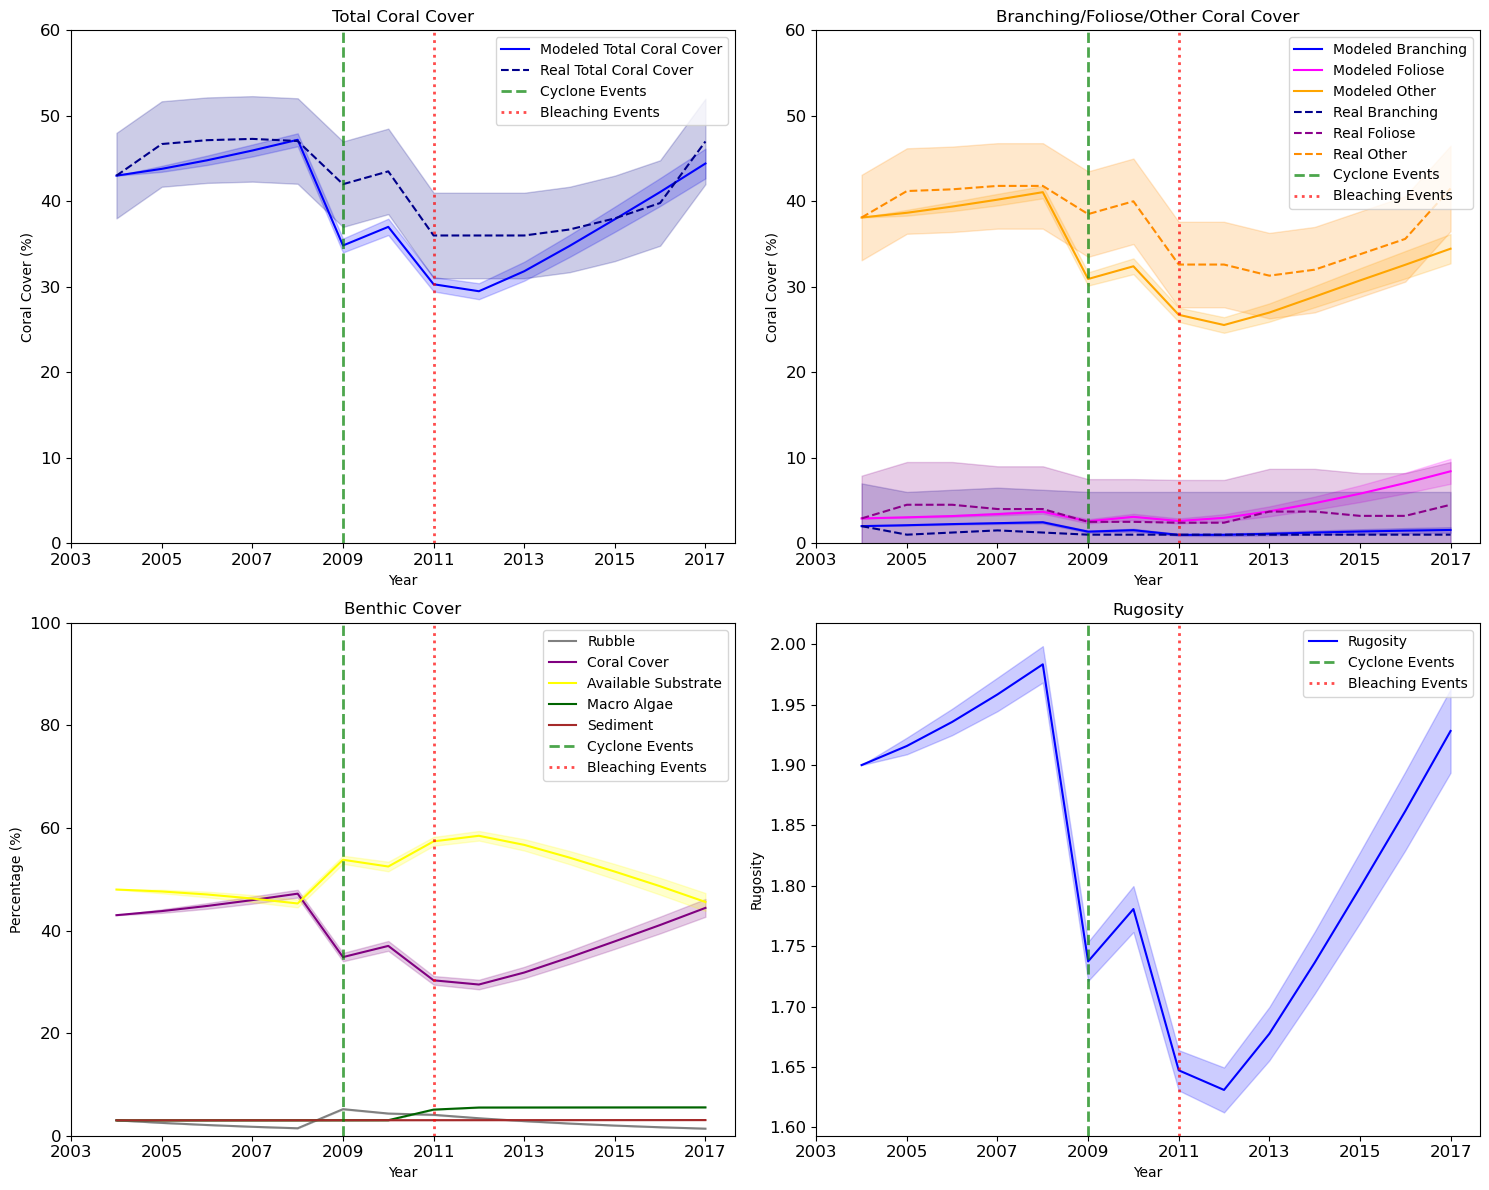

In [31]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Define event years
# Extract years directly from dataframes
year_cyclone = [int(row['Year']) for _, row in cyclone_df.iterrows() if pd.notna(row['Year'])]
year_bleaching = [int(row['Year']) for _, row in dhw_df.iterrows() if pd.notna(row['Year'])]

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total, label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, average_total - std_dev_total, average_total + std_dev_total, color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'], real_df['Total_Coral_Cover (%)'], label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'], real_df['Total_Coral_Cover (%)'] - real_total_margin, real_df['Total_Coral_Cover (%)'] + real_total_margin, color='darkblue', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[0, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[0, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[0, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[0, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend(ncol=1)
axs[0, 0].set_ylim(0, 60)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching, label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose, label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other, label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealBranching_Area (%)'], label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealBranching_Area (%)'] - real_branching_margin, real_df['RealBranching_Area (%)'] + real_branching_margin, color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealFoliose_Area (%)'], label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealFoliose_Area (%)'] - real_foliose_margin, real_df['RealFoliose_Area (%)'] + real_foliose_margin, color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'], real_df['RealOther_Area (%)'], label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'], real_df['RealOther_Area (%)'] - real_other_margin, real_df['RealOther_Area (%)'] + real_other_margin, color='darkorange', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[0, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[0, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[0, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[0, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 60)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[1, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[1, 0].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[1, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[1, 0].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

# Add vertical lines for events
for i, year in enumerate(year_cyclone):
    if i == 0:  # Only add label to the first cyclone line
        axs[1, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Cyclone Events')
    else:
        axs[1, 1].axvline(x=year, color='green', linestyle='--', alpha=0.7, linewidth=2)  # No label

for i, year in enumerate(year_bleaching):
    if i == 0:  # Only add label to the first bleaching line
        axs[1, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Bleaching Events')
    else:
        axs[1, 1].axvline(x=year, color='red', linestyle=':', alpha=0.7, linewidth=2)  # No label

axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

## Create bubble plot for population distribution

Using all available years:
Model years: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Actual years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


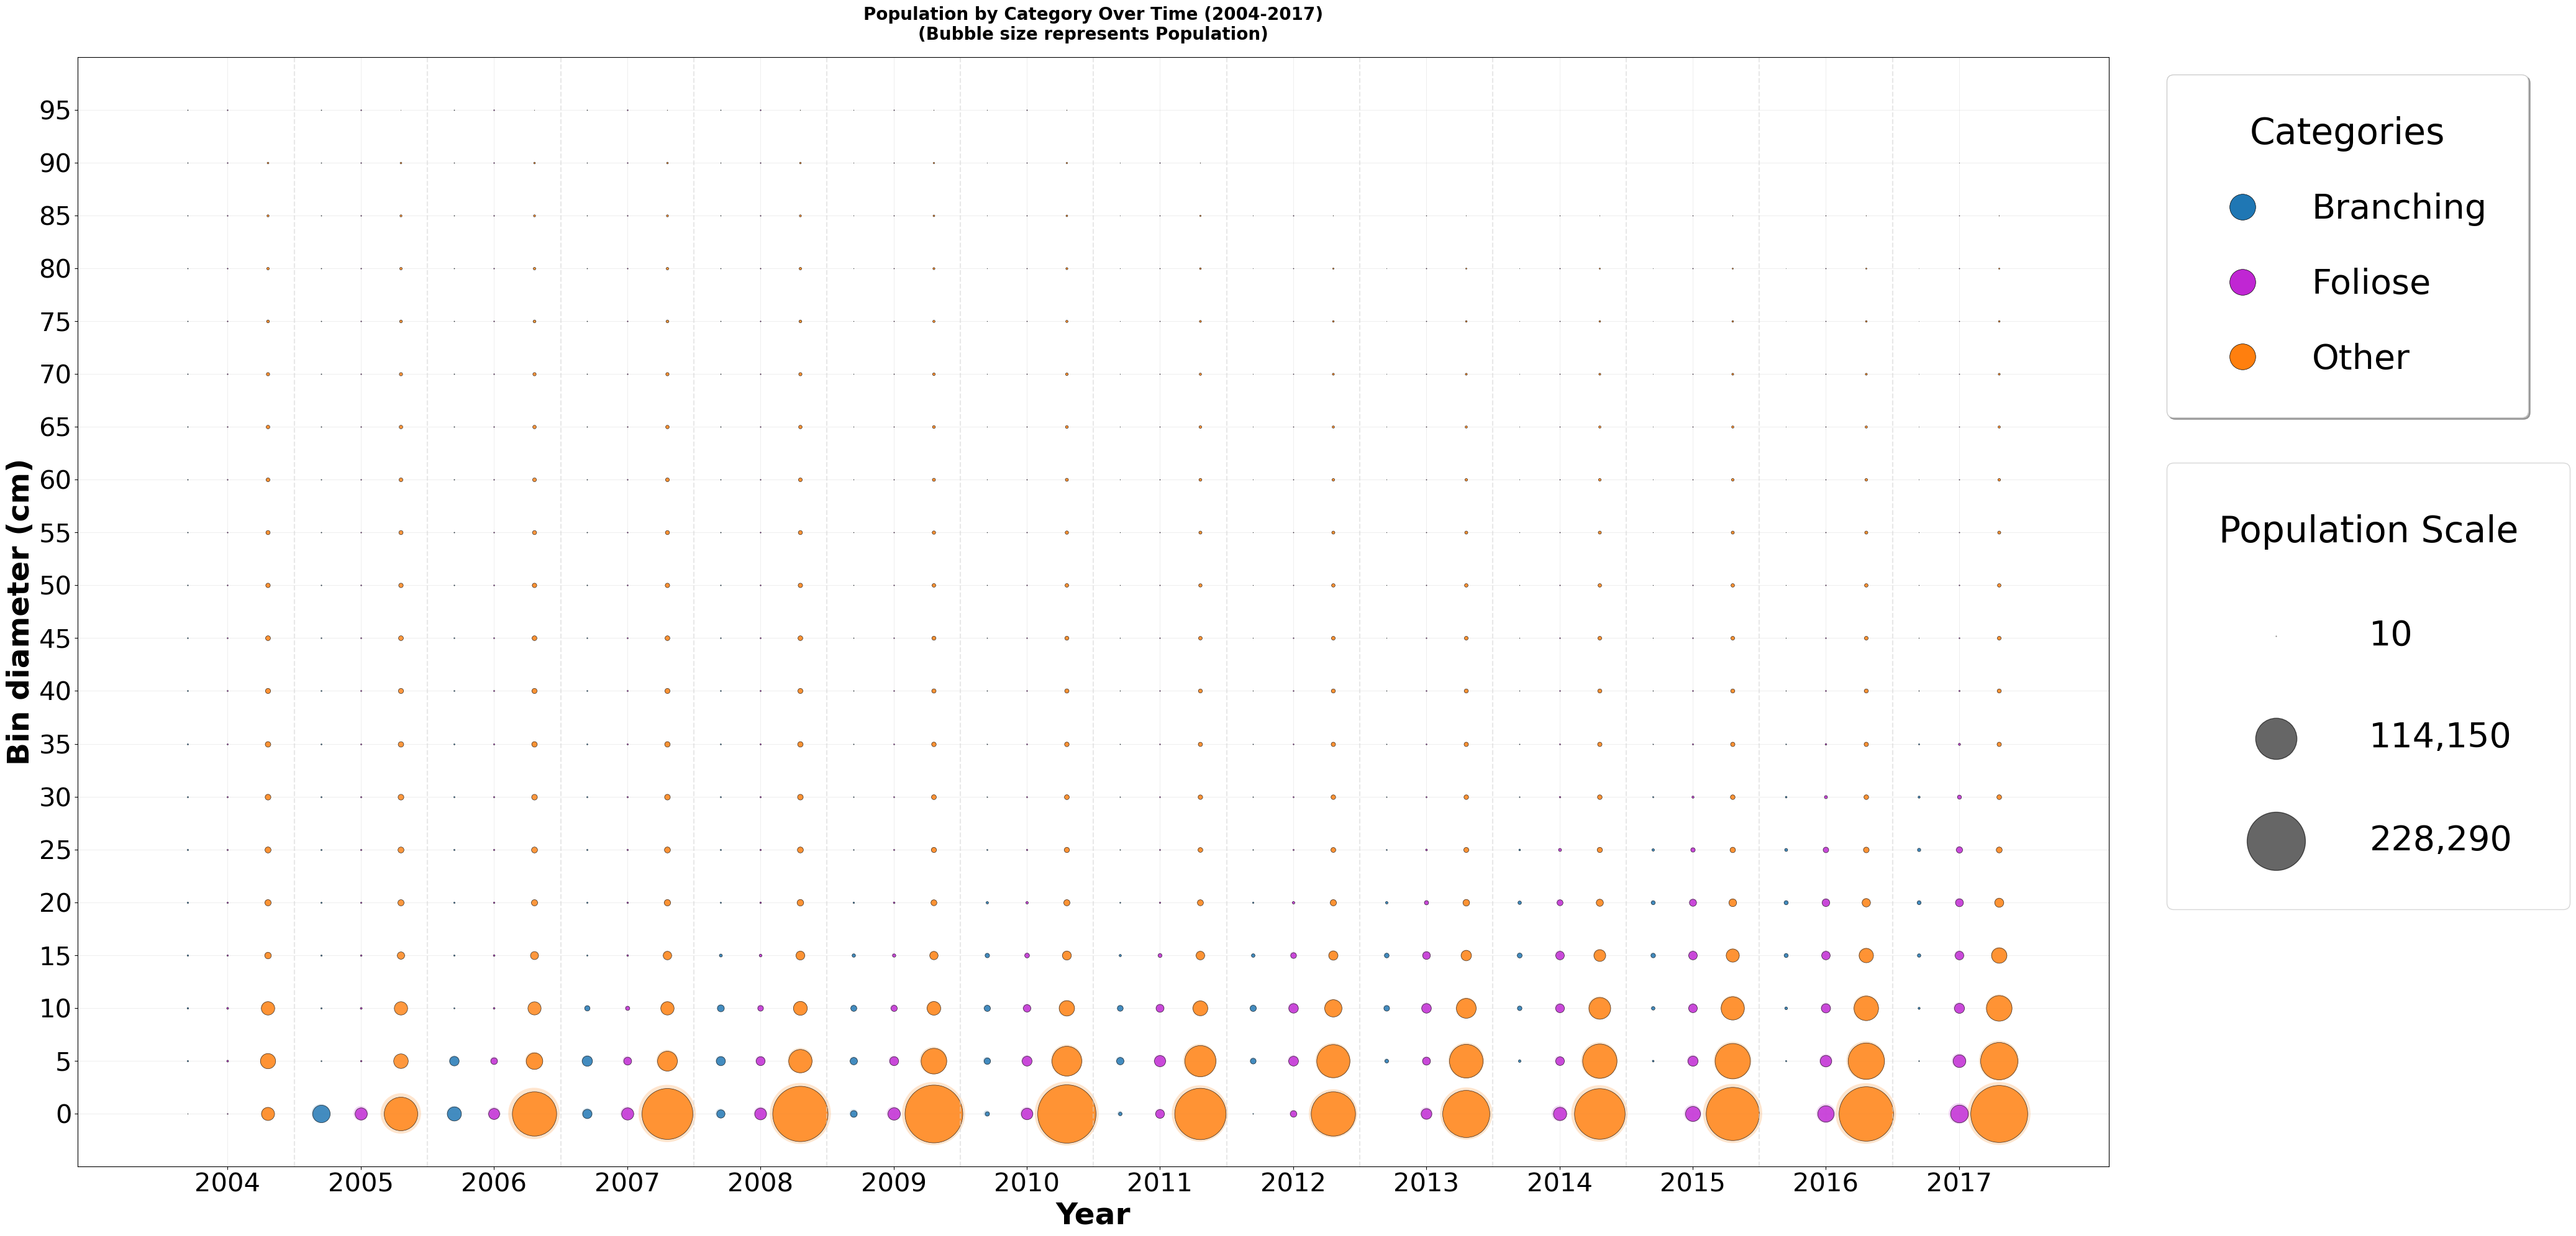

(<Figure size 4000x2000 with 1 Axes>,
 <Axes: title={'center': 'Population by Category Over Time (2004-2017)\n(Bubble size represents Population)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [23]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                selected_years=None, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),
                                y_spacing=5,
                                 title_fontsize=20, 
                                label_fontsize=35, 
                                tick_fontsize=30, 
                                legend_fontsize=40) 

## Create bubble plot for percentage of population distribution

Using all available years:
Model years: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Actual years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


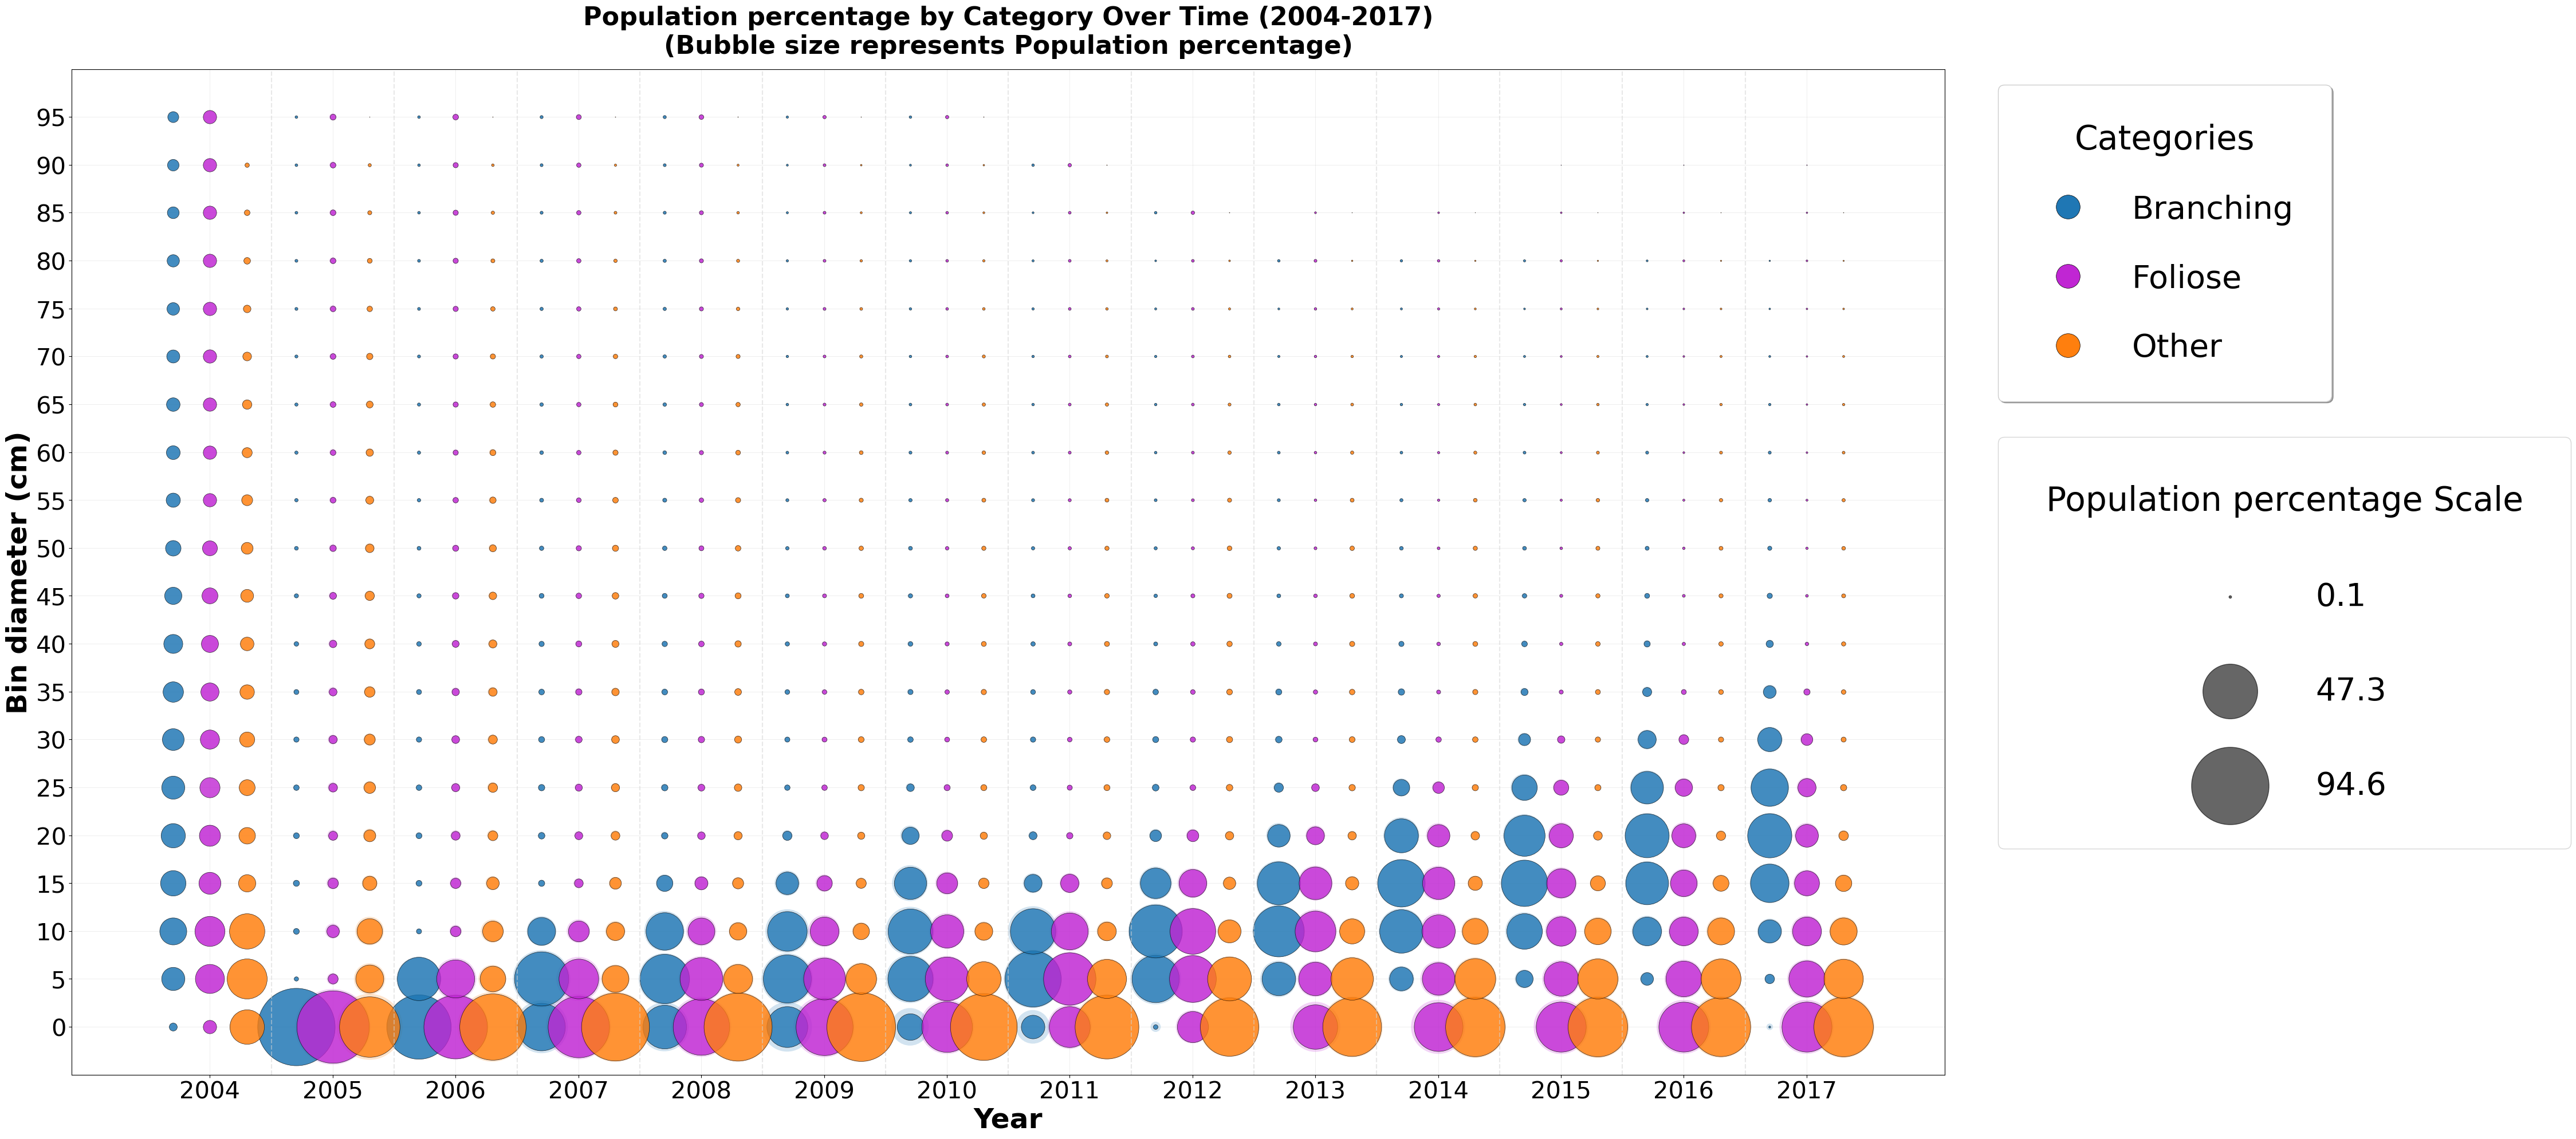

(<Figure size 4000x2000 with 1 Axes>,
 <Axes: title={'center': 'Population percentage by Category Over Time (2004-2017)\n(Bubble size represents Population percentage)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [24]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                selected_years=None, 
                                bubble_scale=100,
                                parallel_offset = 0.5,
                                figsize=(40, 20),
                                y_spacing=5,
                                title_fontsize=32, 
                                label_fontsize=35, 
                                tick_fontsize=30, 
                                legend_fontsize=40) 

## Create bubble plot for area distribution

Using all available years:
Model years: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Actual years: [2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]


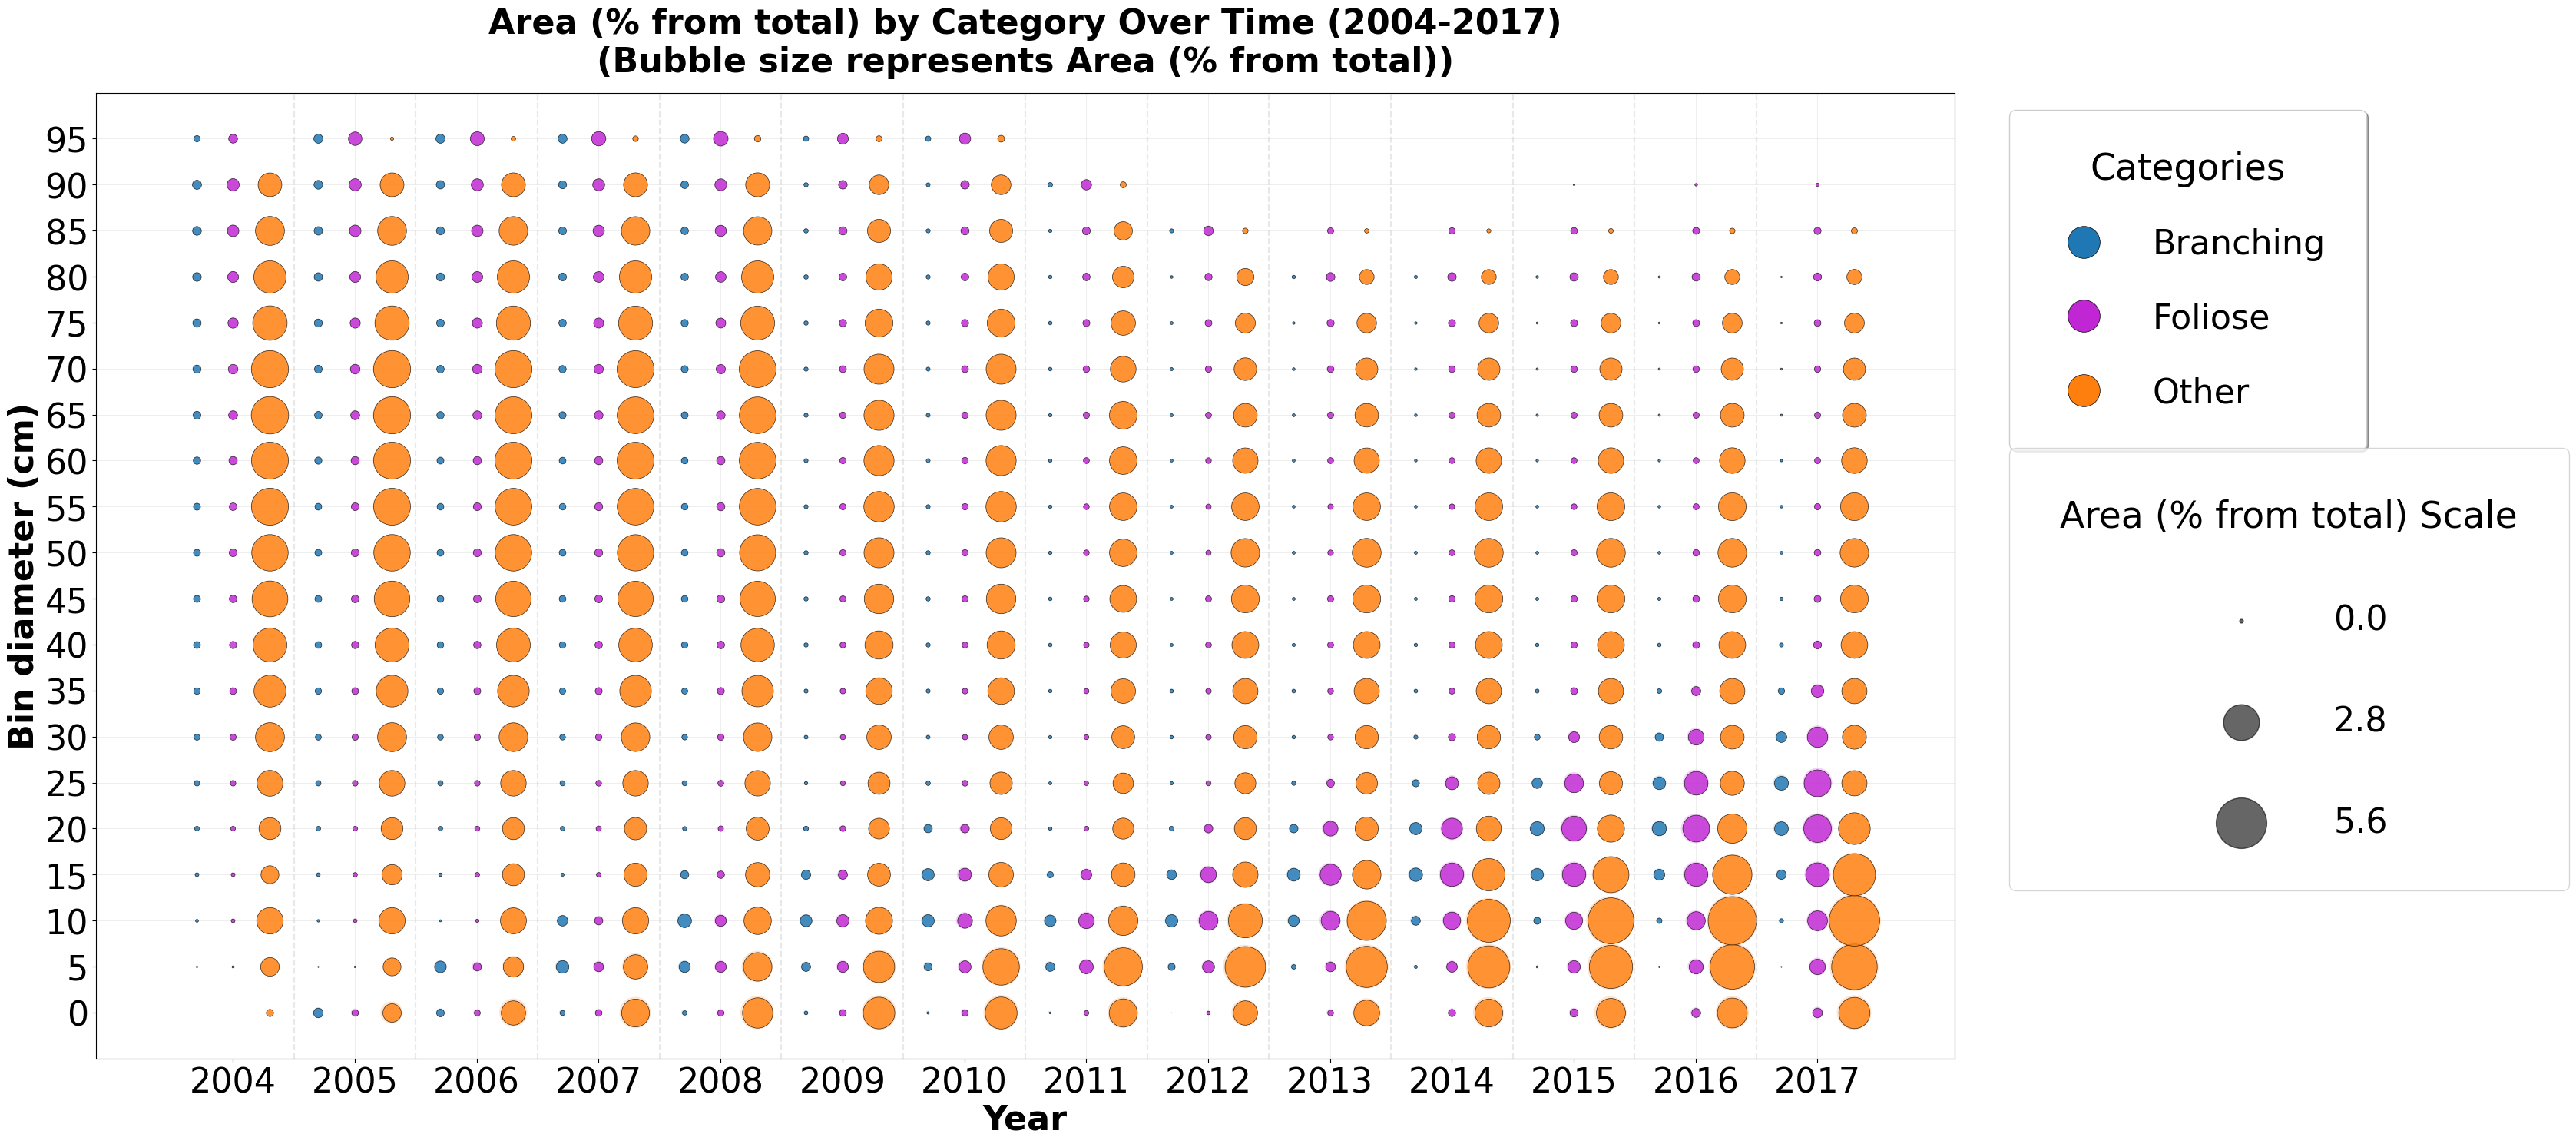

(<Figure size 3000x1500 with 1 Axes>,
 <Axes: title={'center': 'Area (% from total) by Category Over Time (2004-2017)\n(Bubble size represents Area (% from total))'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [28]:
plot_bubble_chart_from_dataframe(area_df, 
                                 title = "Area (% from total)", 
                                 category_col='MG', 
                                 selected_years=None, 
                                bubble_scale=400, 
                                 parallel_offset=3, 
                                 figsize=(30, 15), 
                                 y_spacing=5,
                                  title_fontsize=32, 
                                label_fontsize=32, 
                                tick_fontsize=32, 
                                legend_fontsize=32)

## Calculate and plot average and standard deviation for each morphology based on multiple iterations of model

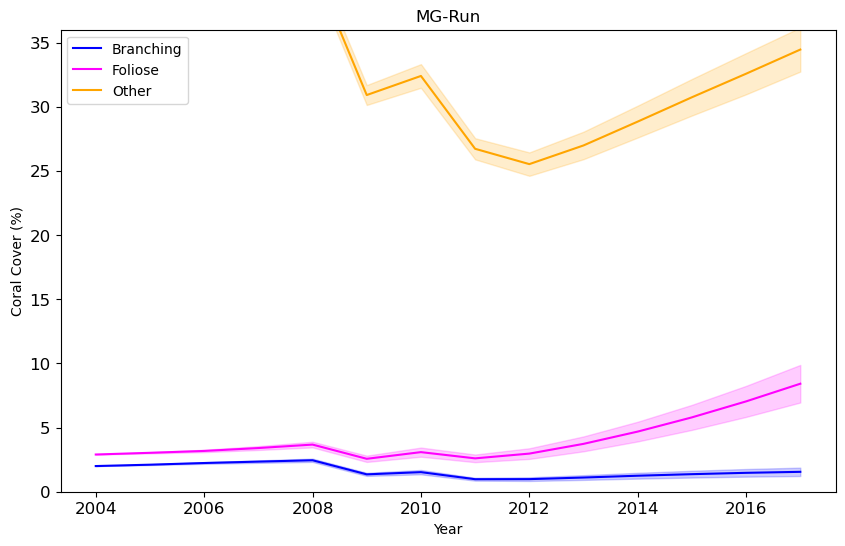

Graph has been saved to output/figures/MG-Run.png


In [26]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

## Plot substrate based on multiple iterations

In [ ]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

## Plot benthic cover based on multiple iterations

In [ ]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years_model = average_rubble.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)  

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

## Plot rugosity based on multiple iterations

In [ ]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years_model = average_rugosity.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int) 

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")

## Predicting the effect of a cyclone on the whole colony mortality

In [ ]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

## The effect of bleaching on the partial colony mortality

In [ ]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching